In [ ]:
!pip install -U langchain langchain-core langchain-groq langgraph pandas sqlite-utils pdfplumber

In [ ]:
import os
import json
import sqlite3
import pandas as pd
from datetime import datetime
import pdfplumber
from typing import TypedDict
from google.colab import userdata

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langgraph.graph import StateGraph

In [ ]:

# LLM Setup (Runnable compatible)
llm = ChatGroq(
    model="qwen/qwen3-32b",
    api_key=userdata.get('GROQ_API_KEY')
)

# Database
conn = sqlite3.connect("cease_desist.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS cease_requests (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    file_name TEXT,
    extracted_text TEXT,
    date TEXT,
    confidence REAL
)
""")
conn.commit()

In [ ]:

# State Definition
class AgentState(TypedDict):
    file_path: str
    file_name: str
    text: str
    classification: str
    reasoning: str
    confidence: float
    final_decision: str

In [ ]:
# Document Loader
def load_pdf(state: AgentState):
    text = ""
    with pdfplumber.open(state["file_path"]) as pdf:
        for page in pdf.pages:
            text += page.extract_text() or ""
    return {**state, "text": text}

loader_node = RunnableLambda(load_pdf)

In [ ]:
# Classifier

prompt = ChatPromptTemplate.from_template('''
Classify the document into either:
- Cease
- Irrelevant

Also give reasoning and a numerical confidence score (0.0-1.0).
This score should reflect your certainty in the classification:
- A confidence score close to 1.0 indicates high certainty that the document is 'Cease'.
- A confidence score close to 0.0 indicates high certainty that the document is 'Irrelevant'.
- A confidence score around 0.5 indicates low certainty or ambiguity.

Text:\n{text}

You must respond ONLY with a JSON object, wrapped in markdown code fences, and nothing else.
Begin your response directly with the JSON. Do NOT include any additional text, thoughts, or explanations before or after the JSON.
```json
{{
  "classification": "",
  "reasoning": "",
  "confidence": 0.0
}}
```
''')

parser = JsonOutputParser()

classifier_chain = (
    RunnablePassthrough()
    | prompt
    | llm
    | parser
)

def classifier_node(state: AgentState):
    result = classifier_chain.invoke({"text": state["text"][:2000]})
    return {
        **state,
        "classification": result["classification"],
        "reasoning": result["reasoning"],
        "confidence": result["confidence"],
    }

classifier_runnable = RunnableLambda(classifier_node)

In [ ]:
# HITL (Human Review)
def human_review(state: AgentState):
    print(f"\nHUMAN REVIEW REQUIRED: {state['file_name']}")
    print(state["text"][:500])
    decision = input("Enter decision (Cease / Irrelevant): ")
    return {**state, "final_decision": decision}

human_node = RunnableLambda(human_review)

In [ ]:
# Auto-decision
def auto_decision(state: AgentState):
    # This node is reached when confidence is < 0.4 or > 0.8
    if state["confidence"] < 0.4:
        final_decision = "Irrelevant"
    elif state["confidence"] > 0.8:
        final_decision = "Cease"
    else:
        # This case should ideally not be reached if the router is correct
        # for the 0.4-0.8 human review range. Default to LLM classification otherwise.
        final_decision = state["classification"]
    return {**state, "final_decision": final_decision}

auto_node = RunnableLambda(auto_decision)

In [ ]:
# Database
def write_db(state: AgentState):
    cursor.execute(
        """
        INSERT INTO cease_requests (file_name, extracted_text, date, confidence)
        VALUES (?, ?, ?, ?)
        """,
        (
            state["file_name"],
            state["text"],
            str(datetime.now()),
            state["confidence"],
        ),
    )
    conn.commit()
    return state

db_node = RunnableLambda(write_db)

In [ ]:
# Audit
def audit_log(state: AgentState):
    log = {
        "file_name": state["file_name"],
        "timestamp": str(datetime.now()),
        "classification": state["classification"],
        "confidence": state["confidence"],
        "final_decision": state["final_decision"],
    }

    with open("audit_log.json", "a") as f:
        f.write(json.dumps(log) + "\n")

    return state


audit_node = RunnableLambda(audit_log)

In [ ]:
# Router
def route(state: AgentState):
    # Route to human review if confidence is between 0.4 and 0.8
    if 0.4 <= state["confidence"] <= 0.8:
        return "human"
    # Otherwise (confidence < 0.4 or > 0.8), route to auto decision
    return "auto"

In [ ]:
# Graph Build

builder = StateGraph(AgentState)

builder.add_node("loader", loader_node)
builder.add_node("classifier", classifier_runnable)
builder.add_node("human", human_node)
builder.add_node("auto", auto_node)
builder.add_node("db", db_node)
builder.add_node("audit", audit_node)

builder.set_entry_point("loader")

builder.add_edge("loader", "classifier")

builder.add_conditional_edges(
    "classifier",
    route,
    {
        "human": "human",
        "auto": "auto",
    },
)

builder.add_edge("human", "db")
builder.add_edge("auto", "db")
builder.add_edge("db", "audit")

builder.set_finish_point("audit")

app = builder.compile()

In [ ]:
PDF_FOLDER = "/content/Data"

pdf_files = [
    os.path.join(PDF_FOLDER, f)
    for f in os.listdir(PDF_FOLDER)
    if f.endswith(".pdf")
]

results = []

for file_path in pdf_files:
    state = {
        "file_path": file_path,
        "file_name": os.path.basename(file_path),
        "text": "",
        "classification": "",
        "reasoning": "",
        "confidence": 0.0,
        "final_decision": "",
    }

    result = app.invoke(state)
    results.append(result)



HUMAN REVIEW REQUIRED: bw_doc_3.pdf

Enter decision (Cease / Irrelevant): Irrelevant

HUMAN REVIEW REQUIRED: LOA6.pdf
I I1 f1
l
j Iii
I'
11 ,,i I
I ' 1 11 ' l ' r11 1 • 1 ' I l ,I ,' II I I 11 'I , 1 I I '
1 • 1 1 'f, 1 II 1 1 , 1, 1 ! , I . 11 I 1 , 1 :1, ·I . 1 ,1 1 1 :I 1 I I ; ~ , ~ , 11 1 I j i' , 1 ,1 '1 , 1 1 ' i I 1 11 I, F 1 iv 1 e ~ 1 ~ k i 1 P e O ~ 11 L ~ !I o a w x; G 8 ' 2 ro 8 u 0 p PLLC.
' Pb~ladelJ~ia, P~1 0~-~280 11 1 , f I f I ' 1 :1 1
,I
t e
I
< ;:h* ' 'I
4
' 9
~
/U
L
t
_
> /
l
; 7 )0
,I
2 ,I ,~
I1
,1 ,
I
,
i!II II
1111 ~
11
;
Jl1 1
1 i
I
I
,
I 1 1 I
I
1
,
j
1 1
'
:
I,1
NurnfirO de cuert ~(r
Enter decision (Cease / Irrelevant): Irrelevant

HUMAN REVIEW REQUIRED: notice_4.pdf

Enter decision (Cease / Irrelevant): Irrelevant

HUMAN REVIEW REQUIRED: notice_2.pdf

Enter decision (Cease / Irrelevant): Irrelevant


In [ ]:
# Results
df = pd.DataFrame(results)
df['decision_type'] = df.apply(lambda row: 'Human' if 0.4 <= row['confidence'] <= 0.8 else 'Auto', axis=1)

In [ ]:
# Select and display the requested columns including 'decision_type'
display(df[[ 'file_name', 'text', 'reasoning', 'confidence', 'classification', 'decision_type']])

,file_name,text,reasoning,confidence,classification,decision_type
0,07_software_license_violation.pdf,"CEASE AND DESIST LETTER\nMichael Brennan, Esq....",The document is a formal cease and desist lett...,0.95,Cease,Auto
1,bw_doc_1.pdf,,The document is empty and contains no content ...,1.00,Irrelevant,Auto
2,LOA8.pdf,DocoSign Envelope ID: AS3E6003-CAAD-4o3S-BOC8•...,The document explicitly states an instruction ...,0.90,Cease,Auto
3,bw_doc_3.pdf,,"The document contains no text, making it impos...",0.50,Irrelevant,Human
4,06_harassment_workplace.pdf,CEASE AND DESIST LETTER\nLinda Fujimoto\n3921 ...,The document is a formal cease and desist lett...,0.99,Cease,Auto
5,notice_5.pdf,,"The document is empty, providing no content to...",0.00,Irrelevant,Auto
6,LOA6.pdf,"I I1 f1\nl\nj Iii\nI'\n11 ,,i I\nI ' 1 11 ' l ...",The document contains explicit instructions to...,0.80,Cease,Human
7,04_defamation_online_review.pdf,CEASE AND DESIST LETTER\nDr. Samantha Ellis\nO...,The document is a formal cease and desist lett...,0.95,Cease,Auto
8,notice_4.pdf,,"The document contains no text, making it impos...",0.50,Irrelevant,Human
9,10_breach_of_contract_nda.pdf,"CEASE AND DESIST LETTER\nKaren Whitfield, Esq....",The document is a formal cease and desist lett...,0.98,Cease,Auto


In [ ]:
# Get the total count of 'Cease' and 'Irrelevant' classifications
classification_counts = df['classification'].value_counts()
display(classification_counts)

classification
Cease         19
Irrelevant    10
Name: count, dtype: int64

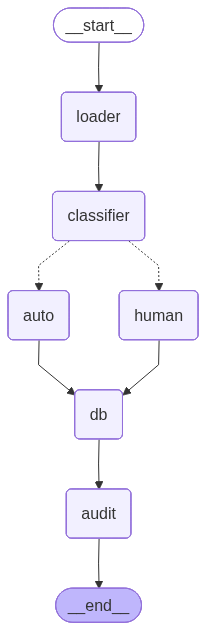

In [ ]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies; ignore if it fails in basic environment
    pass